In [4]:
!pip install geemap
!pip install earthengine-api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 37.0 MB/s eta 0:00:00


In [5]:
import ee
import geemap
import pandas as pd

ee.Authenticate()
ee.Initialize(project='ee-pakjira')

In [6]:
provinces = ee.FeatureCollection("FAO/GAUL/2015/level1")

amnat_charoen = provinces \
    .filter(ee.Filter.eq('ADM0_NAME', 'Thailand')) \
    .filter(ee.Filter.eq('ADM1_NAME', 'Amnat Charoen'))

roi = amnat_charoen.geometry()

In [7]:
def mask_clouds(image):
    scl = image.select('SCL')
    mask = scl.neq(3).And(scl.neq(8))
    return image.updateMask(mask)

In [8]:
def add_indices(image):

    ndvi = image.normalizedDifference(['B8','B4']).rename('NDVI')

    ndmi = image.normalizedDifference(['B8','B11']).rename('NDMI')

    ndwi = image.normalizedDifference(['B3','B8']).rename('NDWI')

    return image.addBands([ndvi, ndmi, ndwi])

In [9]:
rainy = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(roi) \
    .filterDate('2020-08-01','2020-10-01') \
    .map(mask_clouds) \
    .median() \
    .clip(roi)

dry = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(roi) \
    .filterDate('2020-02-01','2020-04-01') \
    .map(mask_clouds) \
    .median() \
    .clip(roi)

In [10]:
rainy = add_indices(rainy)
dry = add_indices(dry)

In [11]:
ndvi_change = rainy.select('NDVI').subtract(dry.select('NDVI'))

ndmi_change = rainy.select('NDMI').subtract(dry.select('NDMI'))

ndwi_change = rainy.select('NDWI').subtract(dry.select('NDWI'))

In [12]:
drought_risk = dry.select('NDVI').lt(0.3) \
    .And(dry.select('NDMI').lt(0)) \
    .clip(roi)

In [13]:
water = dry.select('NDWI').gt(0.3).clip(roi)

moist_area = dry.select('NDMI').gt(0.2).clip(roi)

In [14]:
# Create masks
water = dry.select('NDWI').gt(0.3).clip(roi)
moist_area = dry.select('NDMI').gt(0.2).clip(roi)

# Initialize map
m = geemap.Map(center=[14.99, 103.1], zoom=9)

# Visualization parameters
ndvi_vis = {'min': -1, 'max': 1, 'palette': ['brown', 'yellow', 'green']}
change_vis = {'min': -1, 'max': 1, 'palette': ['red', 'white', 'green']}

# Add layers
m.addLayer(dry.select('NDVI'), ndvi_vis, 'NDVI Dry')
m.addLayer(ndvi_change, change_vis, 'NDVI Change')
m.addLayer(drought_risk.updateMask(drought_risk), {'palette': ['red']}, 'Drought Risk')
m.addLayer(water.updateMask(water), {'palette': ['blue']}, 'Water')
m.addLayer(moist_area.updateMask(moist_area), {'palette': ['cyan']}, 'Moist Area')
m.addLayer(amnat_charoen, {'color': 'black'}, 'Amnat Charoen')

# Display map
m

Map(center=[14.99, 103.1], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGU…

In [15]:
sample = dry.select(['NDVI','NDMI']).sample(
    region=roi,
    scale=30,
    numPixels=5000,
    geometries=False
)

In [16]:
df = geemap.ee_to_df(sample)

df.head()

,NDMI,NDVI
0,-0.222787,0.223245
1,-0.150587,0.336507
2,-0.051288,0.386041
3,-0.022594,0.427269
4,-0.242328,0.239930


In [17]:
correlation = df['NDVI'].corr(df['NDMI'])

print("Correlation between NDVI and NDMI =", correlation)

Correlation between NDVI and NDMI = 0.8224133052822172


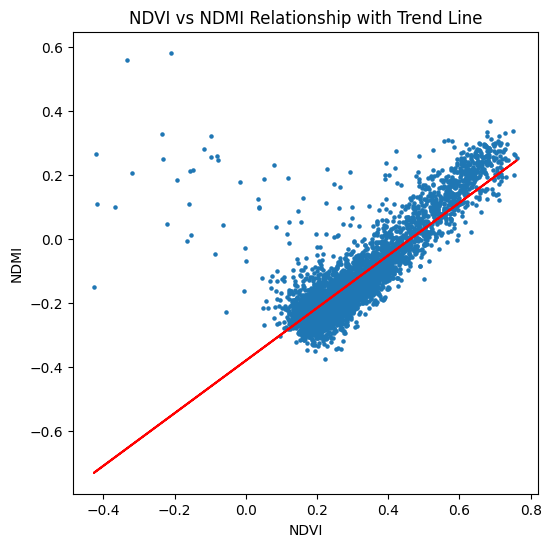

In [18]:
import numpy as np
import matplotlib.pyplot as plt

z = np.polyfit(df['NDVI'], df['NDMI'], 1)
p = np.poly1d(z)

plt.figure(figsize=(6,6))
plt.scatter(df['NDVI'], df['NDMI'], s=5)

plt.plot(df['NDVI'], p(df['NDVI']), color='red')

plt.xlabel("NDVI")
plt.ylabel("NDMI")
plt.title("NDVI vs NDMI Relationship with Trend Line")

plt.show()

In [19]:
task = ee.batch.Export.image.toDrive(
    image=dry.select('NDVI'),
    description='Amnat Charoen_NDVI',
    folder='GEE_exports',
    fileNamePrefix='Amnat Charoen_ndvi',
    region=roi,
    scale=10,
    crs='EPSG:4326',
    fileFormat='GeoTIFF',
    maxPixels=1e13
)

task.start()

print(task.status())

{'state': 'READY', 'description': 'Amnat Charoen_NDVI', 'priority': 100, 'creation_timestamp_ms': 1774927762884, 'update_timestamp_ms': 1774927762884, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': '3FDVN2K6JERXB2WZ5KFTYN6M', 'name': 'projects/ee-pakjira/operations/3FDVN2K6JERXB2WZ5KFTYN6M'}


In [25]:
# ==============================
# Export NDVI Change
# ==============================
task = ee.batch.Export.image.toDrive(
  image=ndvi_change,
  description='NDVI_Change_AmnatCharoen_2020',
  folder='GEE_Export',
  fileNamePrefix='NDVI_Change_2020',
  region=roi,
  scale=10,
  crs='EPSG:4326',
  maxPixels=1e13
)
task.start()
print(task.status())

{'state': 'READY', 'description': 'NDVI_Change_AmnatCharoen_2020', 'priority': 100, 'creation_timestamp_ms': 1774929654643, 'update_timestamp_ms': 1774929654643, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'QRNOZCBC7RB2PT2RYTIKMYTM', 'name': 'projects/ee-pakjira/operations/QRNOZCBC7RB2PT2RYTIKMYTM'}


In [27]:
# ===============================
# Export Drought Risk
# ===============================
task = ee.batch.Export.image.toDrive(
  image=drought_risk,
  description='Drought_Risk_AmnatCharoen_2020',
  folder='GEE_Export',
  fileNamePrefix='Drought_Risk_2020',
  region=roi,
  scale=10,
  crs='EPSG:4326',
  maxPixels=1e13
)
task.start()
print(task.status())

{'state': 'READY', 'description': 'Drought_Risk_AmnatCharoen_2020', 'priority': 100, 'creation_timestamp_ms': 1774929773705, 'update_timestamp_ms': 1774929773705, 'start_timestamp_ms': 0, 'task_type': 'EXPORT_IMAGE', 'id': 'X7PARVSLABYL4T62WCR7SITP', 'name': 'projects/ee-pakjira/operations/X7PARVSLABYL4T62WCR7SITP'}
